In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import umap
import hdbscan
from tqdm.notebook import tqdm

In [15]:
# ── Parameters — mirror UMAP_HDBSCAN.ipynb exactly ───────────────────────────
UMAP_PARAMS = dict(
    n_neighbors  = 15,
    min_dist     = 0.01,
    n_components = 3,
    metric       = "euclidean",
    random_state = 41,
)

HDBSCAN_PARAMS = dict(
    min_cluster_size = 15,
    min_samples      = 5,
    metric           = "euclidean",
)

# How many points to remove at each step
REMOVE_N_VALUES = [10, 20, 30, 40, 50, 60, 70, 80, 100, 125, 150]

# How many random removal repeats per step
N_REPEATS = 50

# Master random seed
RANDOM_SEED = 41

# Path to features CSV (relative to notebook location: Modeling/)
FEATURES_CSV = "../data/non_noise_features.csv"

In [16]:
# ── Load + preprocess ─────────────────────────────────────────────────────────
df_raw = pd.read_csv(FEATURES_CSV)
print(f"Loaded {len(df_raw)} rows, {len(df_raw.columns)} columns")

file_names = df_raw["file_name"].reset_index(drop=True)
X = df_raw.drop(columns=["file_name"]).copy()

X = X.replace({"True": 1, "False": 0, True: 1, False: 0})
X = X.apply(pd.to_numeric, errors="coerce")
non_numeric = X.columns[X.isna().all()].tolist()
if non_numeric:
    print(f"Dropping non-numeric columns: {non_numeric}")
    X = X.drop(columns=non_numeric)
X = X.fillna(X.mean())

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)
print(f"Feature matrix: {X_scaled.shape}")

Loaded 284 rows, 72 columns
Feature matrix: (284, 71)


In [17]:
# ── Full-data ground truth run ────────────────────────────────────────────────
# This single run defines the cluster labels everything else is compared against.

umap_full    = umap.UMAP(**UMAP_PARAMS)
X_umap_full  = umap_full.fit_transform(X_scaled)

hdb_full     = hdbscan.HDBSCAN(**HDBSCAN_PARAMS)
full_labels  = hdb_full.fit_predict(X_umap_full)

n_clusters   = len(set(full_labels)) - (1 if -1 in full_labels else 0)
n_noise      = (full_labels == -1).sum()
print(f"Full-data clusters : {n_clusters}")
print(f"Full-data noise    : {n_noise} / {len(full_labels)}")
print(f"Label counts       : {dict(zip(*np.unique(full_labels, return_counts=True)))}")

c:\Users\HELIOS-300\Desktop\NASA Capstone\NasaDataCapstone\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Full-data clusters : 3
Full-data noise    : 0 / 284
Label counts       : {np.int64(0): np.int64(25), np.int64(1): np.int64(70), np.int64(2): np.int64(189)}


In [18]:
# ── Stability loop ────────────────────────────────────────────────────────────
# For each remove_n: randomly remove that many points N_REPEATS times,
# recluster the remainder with a fresh UMAP+HDBSCAN (same params),
# compare labels on the kept points to the ground truth using ARI.

rng        = np.random.default_rng(RANDOM_SEED)
all_idx    = np.arange(len(X_scaled))
records    = []

for remove_n in tqdm(REMOVE_N_VALUES, desc="Removal sizes"):
    for repeat in range(N_REPEATS):
        removed  = rng.choice(all_idx, size=remove_n, replace=False)
        kept     = np.setdiff1d(all_idx, removed)

        X_red    = X_scaled[kept]

        # Fresh UMAP fit — vary random_state per repeat for diversity
        um = umap.UMAP(**{**UMAP_PARAMS, "random_state": RANDOM_SEED + repeat})
        X_red_umap = um.fit_transform(X_red)

        hdb = hdbscan.HDBSCAN(**HDBSCAN_PARAMS)
        red_labels = hdb.fit_predict(X_red_umap)

        n_cl    = len(set(red_labels)) - (1 if -1 in red_labels else 0)
        n_noise = (red_labels == -1).sum()

        # ARI: compare reduced labels vs ground truth on the kept points only
        ari = adjusted_rand_score(full_labels[kept], red_labels)

        records.append({
            "remove_n" : remove_n,
            "repeat"   : repeat,
            "n_kept"   : len(kept),
            "n_clusters": n_cl,
            "n_noise"  : n_noise,
            "ari"      : ari,
        })

results_df = pd.DataFrame(records)
print("Done.")

Removal sizes:   0%|          | 0/11 [00:00<?, ?it/s]

c:\Users\HELIOS-300\Desktop\NASA Capstone\NasaDataCapstone\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\HELIOS-300\Desktop\NASA Capstone\NasaDataCapstone\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\HELIOS-300\Desktop\NASA Capstone\NasaDataCapstone\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\HELIOS-300\Desktop\NASA Capstone\NasaDataCapstone\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\HELIOS-300\Desktop\NASA Capstone\NasaDataCapstone\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_stat

Done.


In [19]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = (
    results_df
    .groupby("remove_n")
    .agg(
        mean_ari         = ("ari",        "mean"),
        sd_ari           = ("ari",        "std"),
        min_ari          = ("ari",        "min"),
        max_ari          = ("ari",        "max"),
        mean_n_clusters  = ("n_clusters", "mean"),
        mean_noise       = ("n_noise",    "mean"),
        n_repeats        = ("ari",        "count"),
    )
    .reset_index()
)

print(summary.to_string(index=False))

# Save results
out_dir = Path("../data/ari_stability_results")
out_dir.mkdir(parents=True, exist_ok=True)
results_df.to_csv(out_dir / "cam_ari_all_results.csv",   index=False)
summary.to_csv(   out_dir / "cam_ari_summary.csv",       index=False)
print(f"\nSaved to {out_dir.resolve()}")

 remove_n  mean_ari   sd_ari   min_ari  max_ari  mean_n_clusters  mean_noise  n_repeats
       10  0.917710 0.192325  0.322453 1.000000             3.04        0.44         50
       20  0.810216 0.276197  0.316078 1.000000             2.94        0.34         50
       30  0.824022 0.282003  0.215803 1.000000             2.78        0.04         50
       40  0.662697 0.319773  0.290607 1.000000             2.58        0.14         50
       50  0.532383 0.294451  0.204728 1.000000             2.40        0.24         50
       60  0.535667 0.294223  0.280449 1.000000             2.38        0.52         50
       70  0.452920 0.251282  0.286105 1.000000             2.18        0.00         50
       80  0.506001 0.281392  0.292334 1.000000             2.18        3.56         50
      100  0.474555 0.253133  0.169158 1.000000             2.30        5.46         50
      125  0.445361 0.201393  0.149769 1.000000             2.68       13.12         50
      150  0.360621 0.227582 -0.

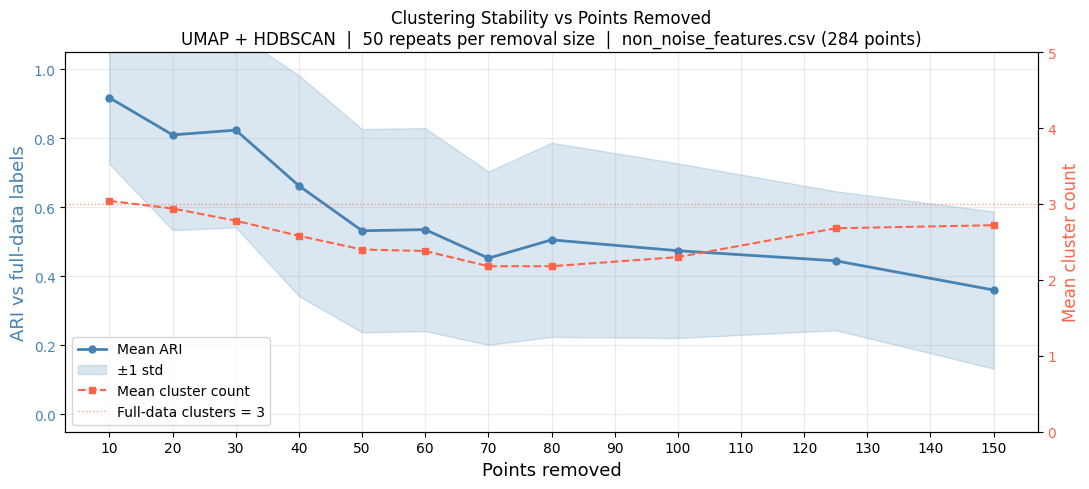

Saved → cam_ari_stability.png


In [20]:
# ── Plot: ARI and cluster count vs removal size ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax1 = plt.subplots(figsize=(11, 5))

x     = summary["remove_n"]
y     = summary["mean_ari"]
y_std = summary["sd_ari"]

ax1.plot(x, y, color="steelblue", linewidth=2, marker="o", markersize=5,
         label="Mean ARI")
ax1.fill_between(x, y - y_std, y + y_std, alpha=0.2, color="steelblue",
                 label="±1 std")
ax1.set_xlabel("Points removed", fontsize=13)
ax1.set_ylabel("ARI vs full-data labels", fontsize=13, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_ylim(-0.05, 1.05)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(x, summary["mean_n_clusters"], color="tomato", linewidth=1.5,
         linestyle="--", marker="s", markersize=4, label="Mean cluster count")
ax2.axhline(len(set(full_labels)) - (1 if -1 in full_labels else 0),
            color="tomato", linewidth=1, linestyle=":", alpha=0.6,
            label=f"Full-data clusters = {len(set(full_labels)) - (1 if -1 in full_labels else 0)}")
ax2.set_ylabel("Mean cluster count", fontsize=12, color="tomato")
ax2.tick_params(axis="y", labelcolor="tomato")
ax2.set_ylim(0, max(summary["mean_n_clusters"].max() + 1, 5))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=10)

ax1.set_title(
    f"Clustering Stability vs Points Removed\n"
    f"UMAP + HDBSCAN  |  {N_REPEATS} repeats per removal size  |  "
    f"non_noise_features.csv ({len(X_scaled)} points)",
    fontsize=12,
)

plt.tight_layout()
plt.savefig("cam_ari_stability.png", dpi=150)
plt.show()
print("Saved → cam_ari_stability.png")